In [7]:
using Plots
using Random
using Statistics

In [20]:
mutable struct DPD
    # scale
    L::Float64          # size
    time::Float64
    iter::Int

    # physical quantities of molecules
    x
    y
    z
    v_x
    v_y
    v_z
    interaction_force_x
    interaction_force_y
    interaction_force_z
    dissipative_force_x
    dissipative_force_y
    dissipative_force_z
    random_force_x
    random_force_y
    random_force_z

    shear::Float64
    Δx::Float64

    repulsive::Float64                  # repulsive interaction force parameter
    dissipative::Float64                # dissipative force parameter

    N::Int                      # total number of molecules
    density::Float64            # number density of molecules

    viscosity::Float64

    # hyper parameters
    dt::Float64
    cutoff_radius::Float64  # cutoff radius of forces

    function _init_size_and_position(N, density; ϵ=0.0001)
        # set molecules at face centered cubic points
        lattice_constant = cbrt(4.0 / density)
        scale = Int(round(cbrt(N / 4.0)))
        L = lattice_constant * scale

        x_vec = []
        y_vec = []
        z_vec = []
        for layer = 1 : 4
            if layer  == 1
                x0 = ϵ - L * 0.5
                y0 = ϵ - L * 0.5
                z0 = ϵ - L * 0.5
            elseif layer == 2
                x0 = 0.5 * lattice_constant - L * 0.5
                y0 = 0.5 * lattice_constant - L * 0.5
                z0 = ϵ - L * 0.5
            elseif layer == 3
                x0 = 0.5 * lattice_constant - L * 0.5
                y0 = ϵ - L * 0.5
                z0 = 0.5 * lattice_constant - L * 0.5
            elseif layer == 4
                x0 = ϵ - L * 0.5
                y0 = 0.5 * lattice_constant - L * 0.5
                z0 = 0.5 * lattice_constant - L * 0.5
            end

            for z_index = 1 : scale
                z = lattice_constant * (z_index - 1) + z0
                if z >= L * 0.5
                    continue
                else
                    for y_index = 1 : scale
                        y = lattice_constant * (y_index - 1) + y0
                        if y >= L * 0.5
                            continue
                        else
                            for x_index = 1 : scale
                                x = lattice_constant * (x_index - 1) + x0
                                if x >= L * 0.5
                                    continue
                                end
                                push!(x_vec, x)
                                push!(y_vec, y)
                                push!(z_vec, z)
                            end
                        end
                    end
                end
            end
        end
        return L, x_vec, y_vec, z_vec
    end

    function DPD(N, density, repulsive, dissipative, shear; dt=0.0002, cutoff_radius=1.0)
        iter = 0
        time = 0.0
        Δx = 0.0
        viscosity = 0.0

        L, x, y, z = _init_size_and_position(N, density)

        interaction_force_x = zeros(N)
        interaction_force_y = zeros(N)
        interaction_force_z = zeros(N)
        dissipative_force_x = zeros(N)
        dissipative_force_y = zeros(N)
        dissipative_force_z = zeros(N)
        random_force_x = zeros(N)
        random_force_y = zeros(N)
        random_force_z = zeros(N)
        v_x = rand(Float64, N) .* 2.0 .- 1.0
        v_y = rand(Float64, N) .* 2.0 .- 1.0
        v_z = rand(Float64, N) .* 2.0 .- 1.0

        new(L, time, iter, x, y, z, v_x, v_y, v_z,
            interaction_force_x, interaction_force_y, interaction_force_z, dissipative_force_x, dissipative_force_y, dissipative_force_z, random_force_x, random_force_y, random_force_z,
            shear, Δx, repulsive, dissipative, N, density, viscosity, dt, cutoff_radius)
    end
end

function show_parameters(dpd)
    println("scale: $(dpd.L) * $(dpd.L) * $(dpd.L)\naverage density: $(dpd.density), # of molecular: $(dpd.N)")
    println("repulsive force parameter: $(dpd.repulsive), dissipative force parameter: $(dpd.dissipative), shear velocity: $(dpd.shear)")
    println("hyper parameters")
    println("dt: $(dpd.dt), cutoff radius: $(dpd.cutoff_radius)")
end

function solve!(dpd, iter_max)
    show_parameters(dpd)

    viscosity_data = []
    force_and_viscosity_update!(dpd)
    println("\nCheck!\naverage velocity is theoreticaly ≈ 1\n")
    while dpd.iter <= iter_max
        time_evolution!(dpd)
        position_update!(dpd)
        velocity_update!(dpd)
        force_and_viscosity_update!(dpd)

        post_loop_process!(dpd, viscosity_data, iter_max)
    end

    show_results(viscosity_data)
    return viscosity_data
end

function time_evolution!(dpd)
    dx = dpd.shear * dpd.L * dpd.time
    dpd.Δx = dx % dpd.L
    dpd.iter += 1
    dpd.time += dpd.dt
end

function force_and_viscosity_update!(dpd)
    viscosity = 0.0
    for i = 1 : dpd.N
        viscosity += dpd.v_y[i] * (dpd.v_x[i] + dpd.y[i] * dpd.shear)
    end

    interaction_force_x = zeros(dpd.N)
    interaction_force_y = zeros(dpd.N)
    interaction_force_z = zeros(dpd.N)
    dissipative_force_x = zeros(dpd.N)
    dissipative_force_y = zeros(dpd.N)
    dissipative_force_z = zeros(dpd.N)
    random_force_x = zeros(dpd.N)
    random_force_y = zeros(dpd.N)
    random_force_z = zeros(dpd.N)
    for i = 1 : dpd.N-1
        int_x_tmp = interaction_force_x[i]
        int_y_tmp = interaction_force_y[i]
        int_z_tmp = interaction_force_z[i]
        dis_x_tmp = dissipative_force_x[i]
        dis_y_tmp = dissipative_force_y[i]
        dis_z_tmp = dissipative_force_z[i]
        rand_x_tmp = random_force_x[i]
        rand_y_tmp = random_force_y[i]
        rand_z_tmp = random_force_z[i]
        for j = i+1 : dpd.N
            distance_x = dpd.x[i] - dpd.x[j]
            distance_y = dpd.y[i] - dpd.y[j]
            distance_z = dpd.z[i] - dpd.z[j]

            # Lees-Edwards boundary condition
            δy = -round(distance_y / dpd.L)
            distance_y += δy * dpd.L
            distance_x += δy * dpd.Δx
            distance_x -= round(distance_x / dpd.L) * dpd.L
            distance_z -= round(distance_z / dpd.L) * dpd.L

            # cutoff
            r_ij = sqrt(distance_x ^ 2 + distance_y ^ 2 + distance_z ^ 2)
            r_cutoff_ratio = r_ij / dpd.cutoff_radius
            if r_cutoff_ratio > 1.0
                continue
            end

            # relative velocity
            relative_velocity_x = (dpd.v_x[i] + dpd.y[i] * dpd.shear) - (dpd.v_x[j] + dpd.y[j] * dpd.shear - δy * dpd.shear * dpd.L)
            relative_velocity_y = dpd.v_y[i] - dpd.v_y[j]
            relative_velocity_z = dpd.v_z[i] - dpd.v_z[j]

            # interaction term
            interaction_potential = (r_cutoff_ratio < 1.0) ? 1.0 - r_cutoff_ratio : 0.0
            n_x = distance_x / r_ij
            n_y = distance_y / r_ij
            n_z = distance_z / r_ij
            interaction_x_ij = interaction_potential * n_x * dpd.repulsive
            interaction_y_ij = interaction_potential * n_y * dpd.repulsive
            interaction_z_ij = interaction_potential * n_z * dpd.repulsive
            int_x_tmp += interaction_x_ij
            int_y_tmp += interaction_y_ij
            int_z_tmp += interaction_z_ij
            interaction_force_x[j] -= interaction_x_ij
            interaction_force_y[j] -= interaction_y_ij
            interaction_force_z[j] -= interaction_z_ij

            # dissipative force term
            coef_dissipative = (relative_velocity_x * n_x + relative_velocity_y * n_y + relative_velocity_z * n_z) * (interaction_potential ^ 2)
            dissipative_x_ij = -coef_dissipative * n_x * dpd.dissipative
            dissipative_y_ij = -coef_dissipative * n_y * dpd.dissipative
            dissipative_z_ij = -coef_dissipative * n_z * dpd.dissipative
            dis_x_tmp += dissipative_x_ij
            dis_y_tmp += dissipative_y_ij
            dis_z_tmp += dissipative_z_ij
            dissipative_force_x[j] -= dissipative_x_ij
            dissipative_force_y[j] -= dissipative_y_ij
            dissipative_force_z[j] -= dissipative_z_ij

            # random force term
            box_muller_1 = sqrt(2.0 * (-log(rand(Float64))))
            box_muller_2 = 2.0 * π * rand(Float64)
            θ = box_muller_1 * cos(box_muller_2)
            random_x_ij = interaction_potential * θ * n_x * sqrt(2.0 * dpd.dissipative)
            random_y_ij = interaction_potential * θ * n_y * sqrt(2.0 * dpd.dissipative)
            random_z_ij = interaction_potential * θ * n_z * sqrt(2.0 * dpd.dissipative)
            rand_x_tmp += random_x_ij
            rand_y_tmp += random_y_ij
            rand_z_tmp += random_z_ij
            random_force_x[j] -= random_x_ij
            random_force_y[j] -= random_y_ij
            random_force_z[j] -= random_z_ij

            viscosity += (interaction_x_ij * dissipative_x_ij) * distance_y
        end
        interaction_force_x[i] = int_x_tmp
        interaction_force_y[i] = int_y_tmp
        interaction_force_z[i] = int_z_tmp
        dissipative_force_x[i] = dis_x_tmp
        dissipative_force_y[i] = dis_y_tmp
        dissipative_force_z[i] = dis_z_tmp
        random_force_x[i] = rand_x_tmp
        random_force_y[i] = rand_y_tmp
        random_force_z[i] = rand_z_tmp
    end

    dpd.interaction_force_x = interaction_force_x
    dpd.interaction_force_y = interaction_force_y
    dpd.interaction_force_z = interaction_force_z
    dpd.dissipative_force_x = dissipative_force_x
    dpd.dissipative_force_y = dissipative_force_y
    dpd.dissipative_force_z = dissipative_force_z
    dpd.random_force_x = random_force_x
    dpd.random_force_y = random_force_y
    dpd.random_force_z = random_force_z

    dpd.viscosity = viscosity
end

function position_update!(dpd)
    for i = 1 : dpd.N
        temp_x = dpd.x[i] + (dpd.v_x[i] + dpd.y[i] * dpd.shear) * dpd.dt
        temp_y = dpd.y[i] + dpd.v_y[i] * dpd.dt
        temp_z = dpd.z[i] + dpd.v_z[i] * dpd.dt

        # Lees-Edwards boundary condition
        δy = round(temp_y / dpd.L)
        temp_x -= δy * dpd.Δx
        dpd.x[i] = temp_x - round(temp_x / dpd.L) * dpd.L
        dpd.y[i] = temp_y - δy * dpd.L
        dpd.z[i] = temp_z - round(temp_z / dpd.L) * dpd.L
    end
end

function velocity_update!(dpd)
    for i = 1 : dpd.N
        dpd.v_x[i] += dpd.interaction_force_x[i] * dpd.dt + dpd.dissipative_force_x[i] * dpd.dt + dpd.random_force_x[i] * sqrt(dpd.dt)
        dpd.v_x[i] -= dpd.v_y[i] * dpd.shear * dpd.dt       # Lees-Edwards term
        dpd.v_y[i] += dpd.interaction_force_y[i] * dpd.dt + dpd.dissipative_force_y[i] * dpd.dt + dpd.random_force_y[i] * sqrt(dpd.dt)
        dpd.v_z[i] += dpd.interaction_force_z[i] * dpd.dt + dpd.dissipative_force_z[i] * dpd.dt + dpd.random_force_z[i] * sqrt(dpd.dt)
    end
end

function post_loop_process!(dpd, viscosity_data, max_iter)
    if dpd.iter > div(max_iter, 2)
        push!(viscosity_data, dpd.viscosity)
    end

    if dpd.iter % div(max_iter, 10) == 0
        v = _average_velocity(dpd)
        println("step: $(dpd.iter) / average velocity: $(v)")
    end
end

function _average_velocity(dpd)
    v = 0.0
    for i = 1 : dpd.N
        v += dpd.v_x[i] ^ 2 + dpd.v_y[i] ^ 2 + dpd.v_z[i] ^ 2
    end
    return v / (3.0 * dpd.N)
end

function show_results(viscosity_data)
    viscosity_average = mean(viscosity_data)
    viscosity_variance = std(viscosity_data)
    println("simulation finished\nviscosity / average: $(viscosity_average), variance: $(viscosity_variance)")
end

show_results (generic function with 1 method)

In [26]:
N = 256
density = 3.16
repulsive = 5.0
dissipative = 50.0
shear = 0.05

dpd = DPD(N, density, repulsive, dissipative, shear)

show_parameters(dpd)

scale: 4.326974085894553 * 4.326974085894553 * 4.326974085894553
average density: 3.16, # of molecular: 256
repulsive force parameter: 5.0, dissipative force parameter: 50.0, shear velocity: 0.05
hyper parameters
dt: 0.0002, cutoff radius: 1.0


In [27]:
iter_max = 100000
data = solve!(dpd, iter_max)

scale: 4.326974085894553 * 4.326974085894553 * 4.326974085894553
average density: 3.16, # of molecular: 256
repulsive force parameter: 5.0, dissipative force parameter: 50.0, shear velocity: 0.05
hyper parameters
dt: 0.0002, cutoff radius: 1.0

Check!
average velocity is theoreticaly ≈ 1

step: 10000 / average velocity: 0.9592436844649138
step: 20000 / average velocity: 1.0249520858664511
step: 30000 / average velocity: 1.0556313842211014
step: 40000 / average velocity: 0.9973557081368342
step: 50000 / average velocity: 0.9590074900705985
step: 60000 / average velocity: 1.0734840089633524
step: 70000 / average velocity: 1.1038989723139527
step: 80000 / average velocity: 0.9813724553356257
step: 90000 / average velocity: 1.0492401065619077
step: 100000 / average velocity: 0.979527179836972
simulation finished
viscosity / average: -8.73614527600056, variance: 83.04091094507157


50001-element Vector{Any}:
 -93.08738933005924
 -98.02169653686256
 -82.93777984402074
 -73.90176380262868
 -79.58629799222004
 -77.61689341114173
 -85.45637304587528
 -75.76354622376522
 -83.65388237842086
 -77.31528020280463
 -72.77309404934967
 -57.42069369850976
 -58.79777598672928
   ⋮
  23.834353714280237
  20.30659354180062
  17.944295662316033
  -1.2378676611362007
  -6.499457409053314
  -4.820973128489458
 -21.28281540655378
 -16.593461109307682
   2.5272343648615494
  19.778280935054866
  20.72871794364069
  15.61893360528423

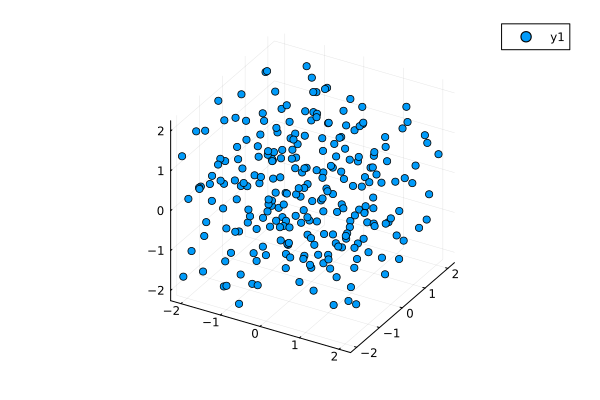

In [28]:
scatter(dpd.x, dpd.y, dpd.z)

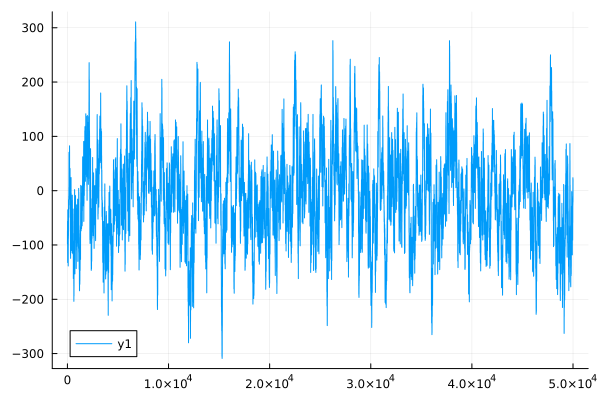

In [29]:
plot(data)